# Generalization Test — do the ~99.9% numbers hold?
### SEA 820 · GenDetect · Classical baseline **and** DistilBERT

Both models score ~99.9% macro-F1 **on the in-distribution test set**. The shortcut analysis
(step 10b of `train_baseline.ipynb`) argued that score rides on *dataset artifacts* — placeholder
tokens, prompt-topic words, formatting. The honest check is to feed the saved models text from a
**different distribution** — short informal writing and real human/AI PDF pairs — and watch whether
accuracy and confidence survive.

> Loads the classical models from `classical_model/classical_results/models/` and the fine-tuned
> DistilBERT from `transformer_model/models/weight/best_model_fulldata/`. Test PDFs live in `test_data/`.

## 0. Setup — load the saved models

In [8]:
# Cross-model generalization test. Runs LOCALLY (repo layout) and on Colab (Drive).
# This notebook now lives in generalization_test/, so it reaches UP to the sibling folders.
import os, sys, numpy as np, joblib

def _find_repo():
    here = os.path.abspath(os.getcwd())
    for cand in (here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))):
        if os.path.isdir(os.path.join(cand, 'classical_model', 'classical_results', 'models')):
            return cand
    return None

def _pick_bert(tdir):
    # Prefer the full-data model; fall back to older layouts if needed.
    for cand in (
        os.path.join(tdir, 'models', 'weight', 'best_model_fulldata'),
        os.path.join(tdir, 'models', 'best_model_fulldata'),
        os.path.join(tdir, 'results', 'best_model'),
    ):
        if os.path.isdir(cand):
            return cand
    return os.path.join(tdir, 'models', 'weight', 'best_model_fulldata') 

REPO = _find_repo()
if REPO:                                                    # local repo checkout
    CLASSICAL_DIR = os.path.join(REPO, 'classical_model')
    DATA_DIR      = os.path.join(REPO, 'data_processing')
    BERT_DIR      = _pick_bert(os.path.join(REPO, 'transformer_model'))
elif os.path.isdir('/content/drive/MyDrive/NLP_project/classical_results/models'):
    from google.colab import drive; drive.mount('/content/drive')
    REPO          = '/content/drive/MyDrive/NLP_project'    # Colab / Drive
    CLASSICAL_DIR = REPO
    DATA_DIR      = REPO
    BERT_DIR      = _pick_bert(os.path.join(REPO, 'transformer_model'))
else:
    raise FileNotFoundError('classical_results/models not found — set REPO by hand.')

MODELS_DIR = os.path.join(CLASSICAL_DIR, 'classical_results', 'models')
for p in (CLASSICAL_DIR, DATA_DIR):                         # tfidf_features + preprocessing
    if p not in sys.path:
        sys.path.insert(0, p)

import tfidf_features as tf
from preprocessing import classical_preprocess              # SAME cleaning used at training time

vec    = joblib.load(os.path.join(MODELS_DIR, 'tfidf_vectorizer.joblib'))
config = joblib.load(os.path.join(MODELS_DIR, 'config.joblib'))
models = {
    'LogReg':    joblib.load(os.path.join(MODELS_DIR, 'LogReg.joblib')),
    'LinearSVC': joblib.load(os.path.join(MODELS_DIR, 'LinearSVC.joblib')),
}

print('repo        :', REPO)
print('classical   :', MODELS_DIR)
print('models      :', list(models.keys()))
print('bert_dir    :', BERT_DIR, '(exists:', os.path.isdir(BERT_DIR), ')')
print('config      :', config)

c:\Users\sakib\Desktop\semester 8\NLP\final_project\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


repo        : c:\Users\sakib\Desktop\semester 8\NLP\final_project
classical   : c:\Users\sakib\Desktop\semester 8\NLP\final_project\classical_model\classical_results\models
models      : ['LogReg', 'LinearSVC']
bert_dir    : c:\Users\sakib\Desktop\semester 8\NLP\final_project\transformer_model\models\weight\best_model_fulldata (exists: True )
config      : {'best_ngram': (1, 2), 'best_maxf': 50000, 'best_C_LR': 10.0, 'best_C_SVM': 10.0, 'use_length': True, 'best_model': 'LinearSVC'}


c:\Users\sakib\Desktop\semester 8\NLP\final_project\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\sakib\Desktop\semester 8\NLP\final_project\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\sakib\Desktop\semester 8\NLP\final_project\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to un

## 1. Prediction helper — labels **and** an AI/human %

**What is a `decision_score`?** A linear model computes `score = w·x + b` — the signed distance
from the decision boundary (the separating hyperplane). `score > 0` -> predict **AI**, `< 0` ->
**human**, and the magnitude is roughly how far from the boundary the text sits (a confidence
proxy). But it is **unbounded** (any real number), so it is *not* a probability.

**Showing "60% AI / 40% human" like online detectors — yes, we can:**
- **Logistic Regression** is probabilistic: its score is a *log-odds*, and `predict_proba`
  squashes it through a **sigmoid** into `P(AI)` / `P(human)`. This is the honest percentage.
- **LinearSVC** has no native probability; we show a *sigmoid of its margin* as a rough
  (uncalibrated) approximation — for a proper % you'd wrap it in `CalibratedClassifierCV`.

We still apply the **same `classical_preprocess`** + fitted vectorizer used at training time.

> ⚠️ **Calibration caveat:** this dataset is trivially separable, so the model is
> **over-confident** — expect ~99% one way and rarely a nuanced 60/40. A middle percentage is
> *not* a reliable "how AI is this" meter; it's another symptom of the shortcut.

In [9]:
def _sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def _featurize(texts):
    cleaned = [classical_preprocess(t, method='lemmatize') for t in texts]
    X = vec.transform(cleaned)
    if config.get('use_length'):
        X = tf.stack_length(X, list(texts))     # match training feature layout
    return X

def predict_text(text, show=True):
    """Return {model: {pred, p_ai, calibrated}} and optionally pretty-print AI/human %."""
    X = _featurize([text])
    res = {}
    for name, mdl in models.items():
        pred = int(mdl.predict(X)[0])                       # 1 = AI, 0 = human
        if hasattr(mdl, 'predict_proba'):                  # LogReg -> real probability
            p_ai, calibrated = float(mdl.predict_proba(X)[0][1]), True
        else:                                              # LinearSVC -> sigmoid(margin), rough
            p_ai, calibrated = float(_sigmoid(mdl.decision_function(X)[0])), False
        res[name] = {'pred': 'AI' if pred else 'human', 'p_ai': p_ai, 'calibrated': calibrated}
    if show:
        print(f'[{len(text.split()):>4} words] "{text[:80].strip()}..."')
        for name, r in res.items():
            tag = '' if r['calibrated'] else '   (uncalibrated approx)'
            print(f'    {name:10s} -> {r["pred"]:5s} | '
                  f'AI {r["p_ai"]*100:5.1f}%  /  human {(1-r["p_ai"])*100:5.1f}%{tag}')
        print()
    return res

In [10]:
# Load the fine-tuned DistilBERT. Uses transformer_text() — the SAME cleaning it trained on.

import torch, torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from preprocessing import transformer_text        

assert os.path.isdir(BERT_DIR), f'best_model not found at {BERT_DIR} — run train_transformer.py or use Colab'

_device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
_tok  = AutoTokenizer.from_pretrained(BERT_DIR)
_bert = AutoModelForSequenceClassification.from_pretrained(BERT_DIR).eval().to(_device)
print('DistilBERT loaded on', _device)

@torch.no_grad()
def predict_bert(text, show=True):
    """Return {pred, p_ai} for DistilBERT, mirroring predict_text()'s interface."""
    clean  = transformer_text(text)
    inputs = _tok(clean, truncation=True, padding=True, max_length=256, return_tensors='pt').to(_device)
    probs  = F.softmax(_bert(**inputs).logits, dim=-1)[0].cpu().numpy()   # [p_human, p_ai]
    p_ai   = float(probs[1]); pred = 'AI' if probs[1] >= probs[0] else 'human'
    if show:
        print(f'[{len(text.split()):>4} words] "{text[:80].strip()}..."')
        print(f'    DistilBERT -> {pred:5s} | AI {p_ai*100:5.1f}%  /  human {(1-p_ai)*100:5.1f}%\n')
    return {'pred': pred, 'p_ai': p_ai}

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT loaded on cpu


## 2. Out-of-distribution short text
A few short samples from *outside* the PERSUADE-essay / AI-essay distribution: casual writing and
modern-chatbot answers. If the ~99.9% were real "AI detection," accuracy here should stay high. If
it was a shortcut, expect it to drop while confidence stays stubbornly high (over-confident + wrong).

In [11]:
# (text, true_label)  -- 0 = human, 1 = AI-generated
OOD = [
    # --- human, but NOT student essays (casual / everyday writing) ---
    ("ok so i finally tried that ramen place downtown lol. line was insane, waited like 40 mins "
     "but honestly worth it. gonna drag my roommate back there next week.", 0),
    ("not gonna lie i completely forgot we had a meeting this morning. woke up late, spilled coffee "
     "on my shirt, bus was delayed... one of those days where nothing goes right you know?", 0),
    # --- AI-generated, from a modern chatbot (not the training generator) ---
    ("Firefox supports the exact same Developer Console script as Chrome. This runs natively in "
     "Firefox without needing to download anything extra:", 1),
    ("I thrive on exploring the bleeding edge of technology, particularly the intersection of "
     "intuitive UI\u2014what I consider strong product taste\u2014and applied AI, including agentic "
     "engineering, large language models, and the Model Context Protocol (MCP).", 1),
    ("Please provide a detailed analysis of the current state of the economy and its potential "
     "impact on the job market.", 1),
]

correct = {name: 0 for name in list(models) + ['DistilBERT']}
for text, true in OOD:
    res = predict_text(text, show=True)                    # classical: LogReg + LinearSVC
    b   = predict_bert(text, show=False)                   # transformer: reuse the same helper
    print(f'    {"DistilBERT":10s} -> {b["pred"]:5s} | '
          f'AI {b["p_ai"]*100:5.1f}%  /  human {(1-b["p_ai"])*100:5.1f}%')
    truth = 'AI' if true else 'human'
    for name, r in res.items():
        correct[name] += (r['pred'] == truth)
    correct['DistilBERT'] += (b['pred'] == truth)
    print(f'    (true label: {truth})')
    print('    ' + '-' * 44)

ood_text_acc = {name: correct[name] / len(OOD) for name in correct}
print('\nAccuracy on this out-of-distribution set:')
for name in correct:
    print(f'   {name:10s}: {correct[name]}/{len(OOD)} = {ood_text_acc[name]:.0%}')
print('\nCompare with ~99.9% on the in-distribution test set. That gap IS the caveat.')

[  29 words] "ok so i finally tried that ramen place downtown lol. line was insane, waited lik..."
    LogReg     -> AI    | AI  99.9%  /  human   0.1%
    LinearSVC  -> AI    | AI  84.5%  /  human  15.5%   (uncalibrated approx)

    DistilBERT -> human | AI   3.3%  /  human  96.7%
    (true label: human)
    --------------------------------------------
[  33 words] "not gonna lie i completely forgot we had a meeting this morning. woke up late, s..."
    LogReg     -> AI    | AI  98.8%  /  human   1.2%
    LinearSVC  -> AI    | AI  74.9%  /  human  25.1%   (uncalibrated approx)

    DistilBERT -> human | AI   0.4%  /  human  99.6%
    (true label: human)
    --------------------------------------------
[  21 words] "Firefox supports the exact same Developer Console script as Chrome. This runs na..."
    LogReg     -> AI    | AI 100.0%  /  human   0.0%
    LinearSVC  -> AI    | AI  87.5%  /  human  12.5%   (uncalibrated approx)

    DistilBERT -> AI    | AI 100.0%  /  human   0.0%
    (

## 3. PDF test — the honest comparison (Classical vs DistilBERT)
The in-distribution test numbers are effectively tied (LinearSVC 0.9997 vs DistilBERT 0.9995
macro-F1), so raw accuracy can't separate the two models. The question that *matters* is
**robustness**: does the Transformer generalize to real documents any better than the
shortcut-exploiting baseline?

The 6 PDFs live in `test_data/` as `human_*` / `ai_*` pairs on 3 shared topics (true label parsed
from the filename). Because each pair shares a topic, this isolates *authorship* from topic: if
`human_0X` and `ai_0X` get the **same** verdict, the model is reading topic/format, not authorship.
We run **both** models on each document.

> Loads DistilBERT from `transformer_model/models/weight/best_model_fulldata/` (auto-detected in Setup).

We run the **classical models in detail** first, then a **cross-model verdict table** (LogReg · LinearSVC · DistilBERT), then a **simple in-distribution-vs-OOD chart**.

In [12]:
# Classical models (LogReg + LinearSVC) on the 6 test_data PDFs — detailed AI%/human%.
import re
import pandas as pd
from pypdf import PdfReader

PDF_DIR = os.path.join(REPO, 'test_data')
pdf_files = [
    'human_01_public_domain.pdf', 'ai_01_public_domain.pdf',
    'human_02_aspirin_pharmacology.pdf', 'ai_02_aspirin_pharmacology.pdf',
    'human_03_aspirin_history.pdf', 'ai_03_aspirin_history.pdf',
]

def read_pdf(path):
    return ' '.join((pg.extract_text() or '') for pg in PdfReader(path).pages)

def true_from_name(fn):
    low = fn.lower()
    return 'AI' if low.startswith('ai_') else ('human' if low.startswith('human_') else '?')

def topic_from_name(fn):
    parts = re.sub(r'\.pdf$', '', fn, flags=re.I).split('_')
    return '_'.join(parts[2:]) if len(parts) > 2 else fn

pdf_texts, rows = {}, []                                    # cache texts so later cells don't re-read
for fn in pdf_files:
    path = os.path.join(PDF_DIR, fn)
    if not os.path.isfile(path):
        rows.append({'file': fn, 'true': true_from_name(fn), 'note': 'FILE NOT FOUND'}); continue
    text = read_pdf(path); pdf_texts[fn] = text; words = len(text.split())
    row = {'file': fn, 'topic': topic_from_name(fn), 'words': words, 'true': true_from_name(fn)}
    if words < 10:
        row['note'] = 'no extractable text (scanned image?)'
    else:
        res = predict_text(text, show=False)
        for name, r in res.items():
            row[name] = r['pred']
            row[f'{name}_AI%'] = round(r['p_ai'] * 100, 1)
            row[f'{name}_human%'] = round((1 - r['p_ai']) * 100, 1)
    rows.append(row)

classical_table = pd.DataFrame(rows)
print('=== Classical models on the 6 test_data PDFs ===')
display(classical_table)

labelled = classical_table[classical_table['true'].isin(['AI', 'human'])
                           & classical_table.get('LogReg', pd.Series(dtype=object)).notna()]
print()
for name in models:
    hits = int((labelled[name] == labelled['true']).sum())
    print(f'{name:10s}: {hits}/{len(labelled)} correct = {hits/len(labelled):.0%}')
print('\nWatch the pairs: same-topic human_0X / ai_0X with the SAME verdict = topic shortcut, not authorship.')

=== Classical models on the 6 test_data PDFs ===


,file,topic,words,true,LogReg,LogReg_AI%,LogReg_human%,LinearSVC,LinearSVC_AI%,LinearSVC_human%
0,human_01_public_domain.pdf,public_domain,621,human,human,14.7,85.3,human,34.4,65.6
1,ai_01_public_domain.pdf,public_domain,461,AI,AI,99.8,0.2,AI,84.3,15.7
2,human_02_aspirin_pharmacology.pdf,aspirin_pharmacology,459,human,human,38.4,61.6,human,36.0,64.0
3,ai_02_aspirin_pharmacology.pdf,aspirin_pharmacology,407,AI,AI,94.7,5.3,AI,64.6,35.4
4,human_03_aspirin_history.pdf,aspirin_history,563,human,AI,97.9,2.1,AI,66.9,33.1
5,ai_03_aspirin_history.pdf,aspirin_history,487,AI,AI,97.1,2.9,AI,66.8,33.2



LogReg    : 5/6 correct = 83%
LinearSVC : 5/6 correct = 83%

Watch the pairs: same-topic human_0X / ai_0X with the SAME verdict = topic shortcut, not authorship.


In [13]:
# Cross-model verdicts on the same 6 PDFs: LogReg + LinearSVC + DistilBERT.
rows, ood_pdf_acc = [], {}
for fn in pdf_files:
    if fn not in pdf_texts:                                 # skip missing / no-text files
        continue
    text = pdf_texts[fn]
    cls = predict_text(text, show=False)                   # classical (LogReg + LinearSVC)
    b   = predict_bert(text, show=False)                   # transformer
    rows.append({
        'file': fn, 'topic': topic_from_name(fn), 'true': true_from_name(fn),
        'LogReg':     cls['LogReg']['pred'],
        'LinearSVC':  cls['LinearSVC']['pred'],
        'DistilBERT': b['pred'],
        'DistilBERT_AI%': round(b['p_ai'] * 100, 1),
    })

cmp = pd.DataFrame(rows)
print('=== Cross-model comparison — 6 PDFs ===')
display(cmp)

print()
for name in ('LogReg', 'LinearSVC', 'DistilBERT'):
    hits = int((cmp[name] == cmp['true']).sum())
    ood_pdf_acc[name] = hits / len(cmp)
    print(f'{name:11s} OOD PDF accuracy: {hits}/{len(cmp)} = {hits/len(cmp):.0%}')

cmp.to_csv('ood_pdf_comparison.csv', index=False)
print('\nSaved -> generalization_test/ood_pdf_comparison.csv')
print('Key question: does DistilBERT get the aspirin_history pair RIGHT where the classical models')
print('both fail (same verdict for human & AI)? That is real authorship signal vs the topic shortcut.')

=== Cross-model comparison — 6 PDFs ===


,file,topic,true,LogReg,LinearSVC,DistilBERT,DistilBERT_AI%
0,human_01_public_domain.pdf,public_domain,human,human,human,AI,99.3
1,ai_01_public_domain.pdf,public_domain,AI,AI,AI,AI,100.0
2,human_02_aspirin_pharmacology.pdf,aspirin_pharmacology,human,human,human,AI,100.0
3,ai_02_aspirin_pharmacology.pdf,aspirin_pharmacology,AI,AI,AI,AI,100.0
4,human_03_aspirin_history.pdf,aspirin_history,human,AI,AI,AI,100.0
5,ai_03_aspirin_history.pdf,aspirin_history,AI,AI,AI,AI,100.0



LogReg      OOD PDF accuracy: 5/6 = 83%
LinearSVC   OOD PDF accuracy: 5/6 = 83%
DistilBERT  OOD PDF accuracy: 3/6 = 50%

Saved -> generalization_test/ood_pdf_comparison.csv
Key question: does DistilBERT get the aspirin_history pair RIGHT where the classical models
both fail (same verdict for human & AI)? That is real authorship signal vs the topic shortcut.


=== In-distribution vs out-of-distribution ===


,in-distribution (macro-F1),OOD short text (accuracy),OOD 6-PDF (accuracy)
LogReg,1.0,0.6,0.833
LinearSVC,1.0,0.6,0.833
DistilBERT,1.0,1.0,0.500


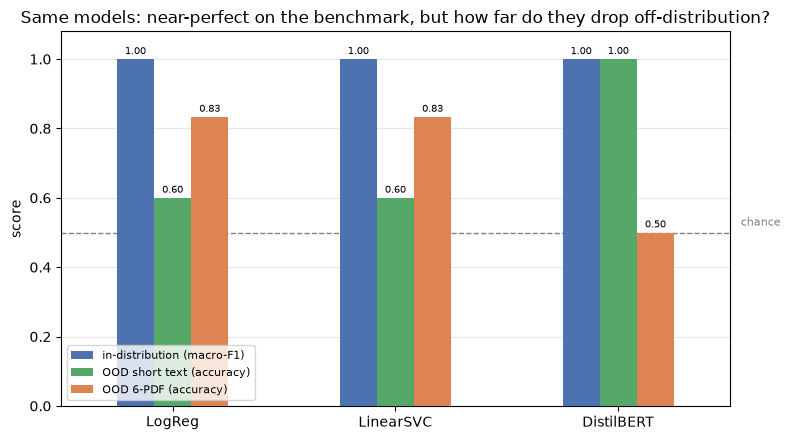

Saved -> generalization_test/ood_vs_indist.png

Left bars (benchmark) all ~1.0 and indistinguishable; the OOD bars are the honest
comparison. Whichever model drops LEAST is the more robust one.


In [14]:
# Final comparison — in-distribution vs out-of-distribution, all 3 models.
import matplotlib.pyplot as plt

INDIST_F1 = {'LogReg': 0.9995, 'LinearSVC': 0.9997, 'DistilBERT': 0.9995}   # from the test-set reports
order = ['LogReg', 'LinearSVC', 'DistilBERT']
summary = pd.DataFrame({
    'in-distribution (macro-F1)': [INDIST_F1[m] for m in order],
    'OOD short text (accuracy)':  [ood_text_acc.get(m, float('nan')) for m in order],
    'OOD 6-PDF (accuracy)':       [ood_pdf_acc.get(m, float('nan')) for m in order],
}, index=order)

print('=== In-distribution vs out-of-distribution ===')
display(summary.round(3))

ax = summary.plot(kind='bar', figsize=(8, 4.5), rot=0,
                  color=['#4C72B0', '#55A868', '#DD8452'], zorder=3)
ax.set_ylim(0, 1.08); ax.set_ylabel('score')
ax.set_title('Same models: near-perfect on the benchmark, but how far do they drop off-distribution?')
ax.axhline(0.5, ls='--', lw=1, color='grey', zorder=1)
ax.text(2.55, 0.52, 'chance', color='grey', fontsize=8)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=7, padding=2)
ax.legend(loc='lower left', fontsize=8); ax.grid(axis='y', alpha=0.3, zorder=0)
plt.tight_layout(); plt.savefig('ood_vs_indist.png', dpi=120, bbox_inches='tight'); plt.show()
print('Saved -> generalization_test/ood_vs_indist.png')
print('\nLeft bars (benchmark) all ~1.0 and indistinguishable; the OOD bars are the honest')
print('comparison. Whichever model drops LEAST is the more robust one.')

## Caveat, stated plainly
A supervised model's eval score is only trustworthy **on data drawn from the same distribution as
its training set**. This baseline is near-perfect on the PERSUADE-vs-AI-essay data it was built
on, but the generalization test above shows the score **does not carry over** to arbitrary
documents — it keys on dataset artifacts, not universal signals of machine-generated text. Report
the baseline honestly with this limitation, and treat the Week-2 Transformer comparison as
"same-dataset", not "real-world AI detection".